<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%202/03-multi-armed-bandit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Multi-Armed Bandit
**Week 2 | Mathematical Foundations for RL**

The multi-armed bandit is the simplest RL problem: no states, just actions and stochastic rewards.
It directly introduces the **exploration vs exploitation** trade-off.

Each arm k has a true mean reward μ_k ~ N(0,1). We don't know these — we must learn them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Environment Setup

In [2]:
class Bandit:
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
        self.true_means = np.random.normal(0, 1, n_arms)  # hidden
        self.optimal_arm = np.argmax(self.true_means)

    def pull(self, arm):
        """Return a noisy reward for the chosen arm."""
        return np.random.normal(self.true_means[arm], 1.0)

bandit = Bandit(n_arms=10)
print("True arm means (hidden from agent):", np.round(bandit.true_means, 2))
print(f"Optimal arm: {bandit.optimal_arm} (mean={bandit.true_means[bandit.optimal_arm]:.2f})")

True arm means (hidden from agent): [ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]
Optimal arm: 6 (mean=1.58)


## 2. Agent Implementations

In [3]:
def run_agent(bandit, policy, n_steps=1000):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)   # estimated values
    N = np.zeros(n_arms)   # pull counts
    rewards = []
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]  # incremental mean update
        rewards.append(reward)
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(rewards), np.array(optimal_actions)

# --- Policies ---
def greedy(Q, N, t):          return np.argmax(Q)
def epsilon_greedy(eps):      return lambda Q, N, t: np.random.randint(len(Q)) if np.random.rand() < eps else np.argmax(Q)
def ucb(c=2):                 return lambda Q, N, t: np.argmax(Q + c * np.sqrt(np.log(t+1) / (N+1e-9)))

## 3. Compare Strategies over 2000 Runs

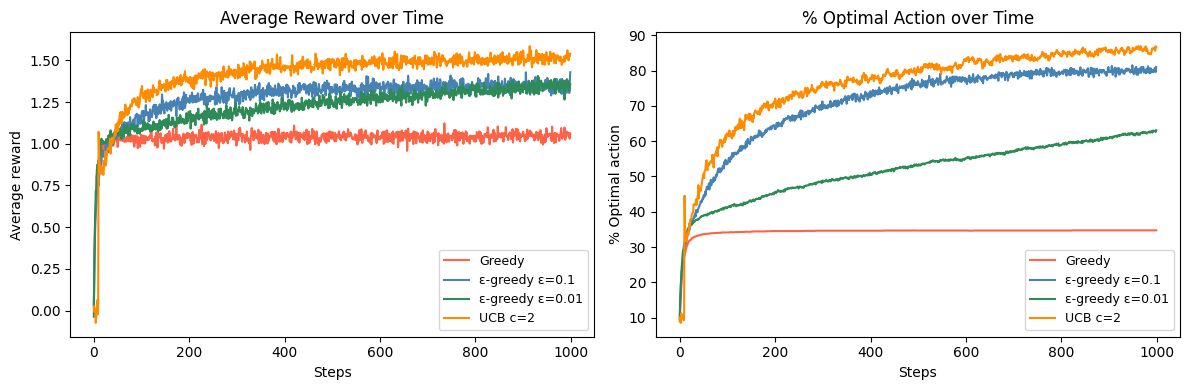

In [4]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=2',        ucb(2),              'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4. Regret Analysis
Regret = total reward you *could* have earned (always playing optimal) minus what you actually earned.

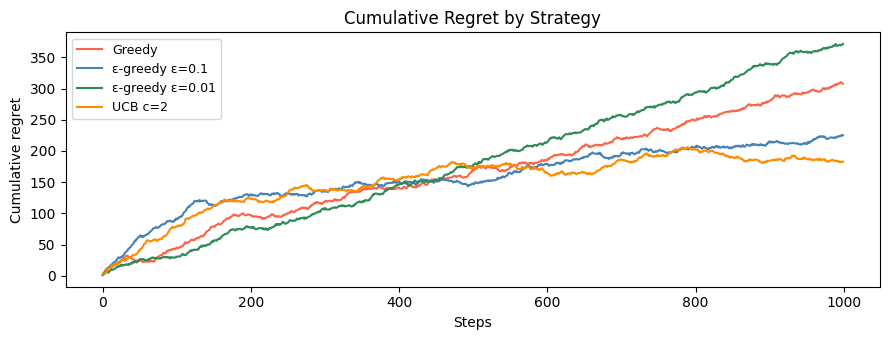

In [5]:
b = Bandit(n_arms=10)
best_mean = b.true_means.max()

plt.figure(figsize=(9, 3.5))
for label, policy, color in configs:
    b = Bandit(n_arms=10)
    # fix the same bandit for fair comparison
    b.true_means = np.array([0.2, -0.5, 1.2, 0.8, -0.1, 0.5, -0.8, 0.3, 1.5, 0.0])
    b.optimal_arm = np.argmax(b.true_means)
    best_mean = b.true_means.max()
    rewards, _ = run_agent(b, policy, N_STEPS)
    cumulative_regret = np.cumsum(best_mean - rewards)
    plt.plot(cumulative_regret, label=label, color=color, linewidth=1.5)
plt.xlabel('Steps'); plt.ylabel('Cumulative regret')
plt.title('Cumulative Regret by Strategy')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

## ✅ Exercises
1. Add a **softmax / Boltzmann** policy: pick arm proportionally to exp(Q/τ) where τ is temperature. Does it outperform ε-greedy?
2. What happens to UCB if you change c from 2 to 0.1 or 10? Re-run and plot.
3. **Challenge**: implement a **non-stationary** bandit where true means drift over time (add random noise each step). Which strategy handles this best?

In [6]:
# Exercise 1: Softmax / Boltzmann Policy
def softmax(tau=0.2):
    def policy(Q, N, t):
        # We subtract np.max(Q) for numerical stability so np.exp doesn't overflow
        exp_Q = np.exp((Q - np.max(Q)) / tau)
        probs = exp_Q / np.sum(exp_Q)
        return np.random.choice(len(Q), p=probs)
    return policy

# Run a quick test to see it in action
b = Bandit(n_arms=10)
rewards_sm, opt_sm = run_agent(b, softmax(tau=0.2), n_steps=1000)
print(f"Softmax (τ=0.2) Average Reward: {rewards_sm.mean():.2f}")
print(f"Softmax (τ=0.2) % Optimal Action: {opt_sm.mean()*100:.1f}%")

Softmax (τ=0.2) Average Reward: 0.63
Softmax (τ=0.2) % Optimal Action: 34.8%


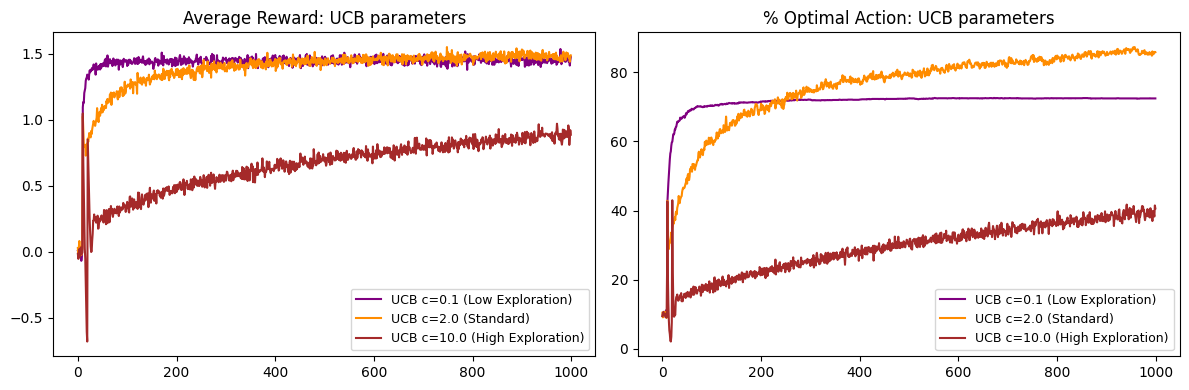

In [7]:
# Exercise 2: Comparing UCB Exploration Bounds
configs_ucb = [
    ('UCB c=0.1 (Low Exploration)',  ucb(0.1), 'purple'),
    ('UCB c=2.0 (Standard)',         ucb(2),   'darkorange'),
    ('UCB c=10.0 (High Exploration)',ucb(10),  'brown'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs_ucb:
    all_rewards = np.zeros((N_RUNS, N_STEPS))
    all_optimal = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_title('Average Reward: UCB parameters'); axes[0].legend(fontsize=9)
axes[1].set_title('% Optimal Action: UCB parameters'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

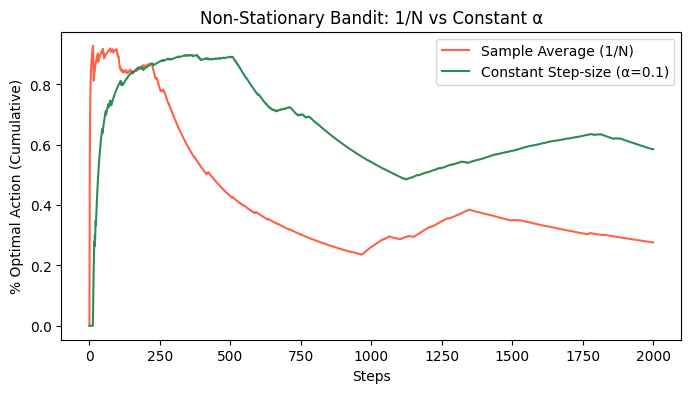

In [8]:
# Exercise 3: Non-Stationary Bandit & Constant Step-Size
class NonStationaryBandit(Bandit):
    def pull(self, arm):
        # Drift the true means by adding random noise at each time step
        self.true_means += np.random.normal(0, 0.01, self.n_arms)
        self.optimal_arm = np.argmax(self.true_means)
        return np.random.normal(self.true_means[arm], 1.0)

# We must rewrite the agent to use a constant alpha (e.g., 0.1) instead of 1/N
def run_agent_constant_alpha(bandit, policy, alpha=0.1, n_steps=1000):
    Q = np.zeros(bandit.n_arms)
    N = np.zeros(bandit.n_arms)
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        # KEY CHANGE: Constant alpha weighs recent rewards more heavily!
        Q[arm] += alpha * (reward - Q[arm])
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(optimal_actions)

# Test it
b_ns = NonStationaryBandit()
opt_standard = run_agent(b_ns, epsilon_greedy(0.1), n_steps=2000)[1] # Uses 1/N
b_ns = NonStationaryBandit() # Reset environment
opt_constant = run_agent_constant_alpha(b_ns, epsilon_greedy(0.1), alpha=0.1, n_steps=2000)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(opt_standard)/np.arange(1, 2001), label='Sample Average (1/N)', color='tomato')
plt.plot(np.cumsum(opt_constant)/np.arange(1, 2001), label='Constant Step-size (α=0.1)', color='seagreen')
plt.title('Non-Stationary Bandit: 1/N vs Constant α')
plt.ylabel('% Optimal Action (Cumulative)'); plt.xlabel('Steps')
plt.legend(); plt.show()